In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load Dataset
df = pd.read_excel("../data/raw/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
#Understand Datasetdf.shape

(541909, 8)

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [ ]:
#Check Missing Values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
#Remove Missing Customers
df = df.dropna(subset=['CustomerID'])

In [10]:
df = df.dropna(subset=['Description'])

In [11]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
#Remove Canceled Orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [13]:
#Remove Negative Quantities
df = df[df['Quantity'] > 0]

In [14]:
#Create Revenue Column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [15]:
#Convert Date Column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [16]:
#Save Clean Dataset
df.to_csv("../data/processed/clv_cleaned.csv", index=False)

In [17]:
#Calculate Customer Metrics
customer_data = df.groupby('CustomerID').agg({
    'Revenue':'sum',
    'InvoiceNo':'nunique',
    'InvoiceDate':['min','max']
})

In [18]:
customer_data.columns = ['TotalRevenue','TotalOrders','FirstPurchase','LastPurchase']

In [19]:
#Calculate Customer Lifespan
customer_data['Lifespan'] = (customer_data['LastPurchase'] - customer_data['FirstPurchase']).dt.days

In [20]:
#Calculate Average Order Value
customer_data['AverageOrderValue'] = customer_data['TotalRevenue'] / customer_data['TotalOrders']

In [21]:
#Calculate Purchase Frequency
customer_data['PurchaseFrequency'] = customer_data['TotalOrders'] / customer_data['Lifespan']

In [22]:
#Calculate CLV
customer_data['CLV'] = customer_data['AverageOrderValue'] * customer_data['PurchaseFrequency'] * customer_data['Lifespan']

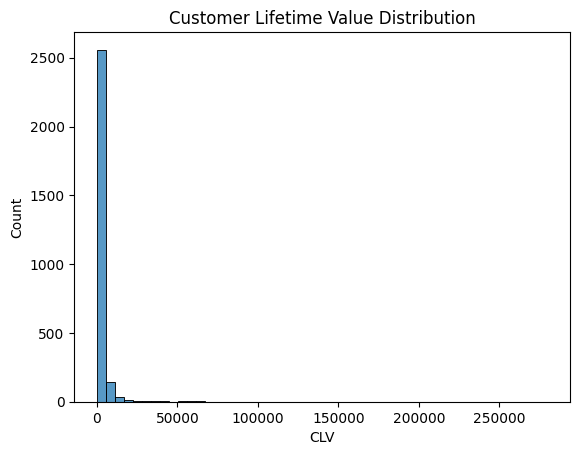

In [23]:
#Visualize CLV Distribution
plt.figure()
sns.histplot(customer_data['CLV'], bins=50)
plt.title("Customer Lifetime Value Distribution")
plt.show()

In [24]:
plt.savefig("../visuals/clv_distribution.png")

<Figure size 640x480 with 0 Axes>

In [25]:
#RFM Customer Segmentation
snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x:(snapshot_date - x.max()).days,
    'InvoiceNo':'nunique',
    'Revenue':'sum'
})

In [26]:
rfm.columns=['Recency','Frequency','Monetary']

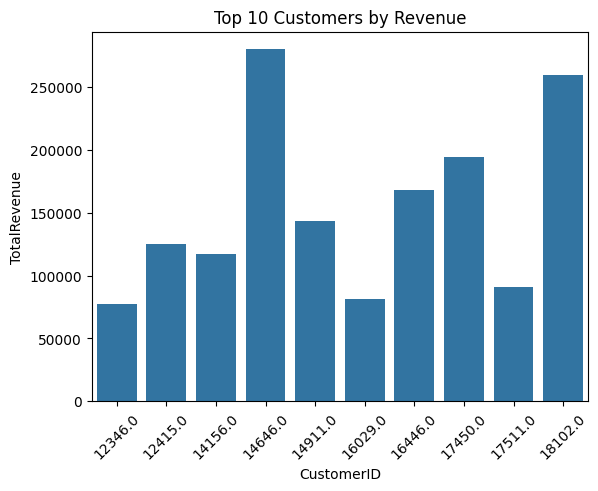

In [27]:
#1️⃣ Top 10 Customers by Revenue
top_customers = customer_data.sort_values('TotalRevenue', ascending=False).head(10)

plt.figure()
sns.barplot(x=top_customers.index, y=top_customers['TotalRevenue'])
plt.xticks(rotation=45)
plt.title("Top 10 Customers by Revenue")
plt.show()

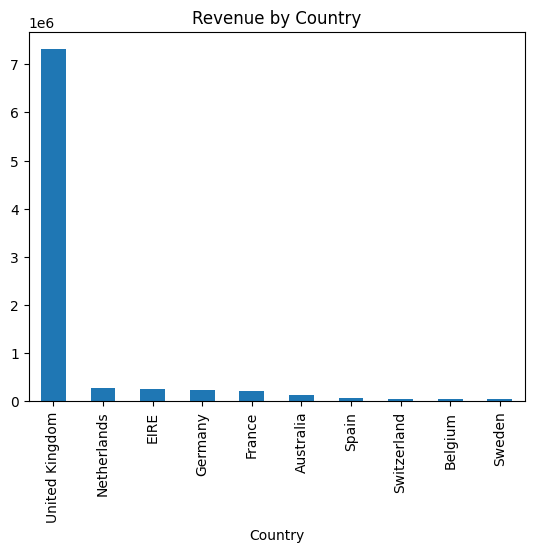

In [28]:
#2️⃣ Revenue by Country
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

plt.figure()
country_revenue.head(10).plot(kind='bar')
plt.title("Revenue by Country")
plt.show()

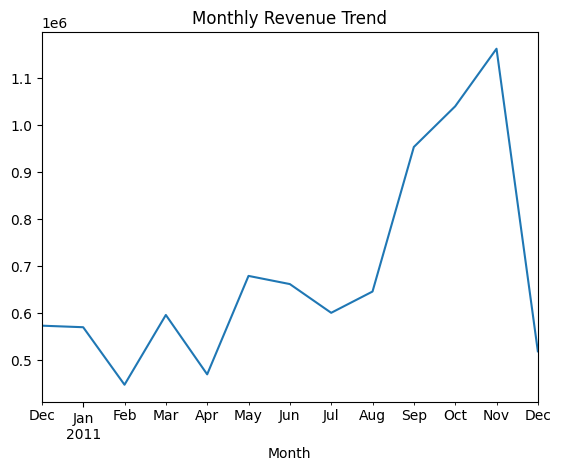

In [29]:
#3️⃣ Monthly Revenue Trend
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.show()

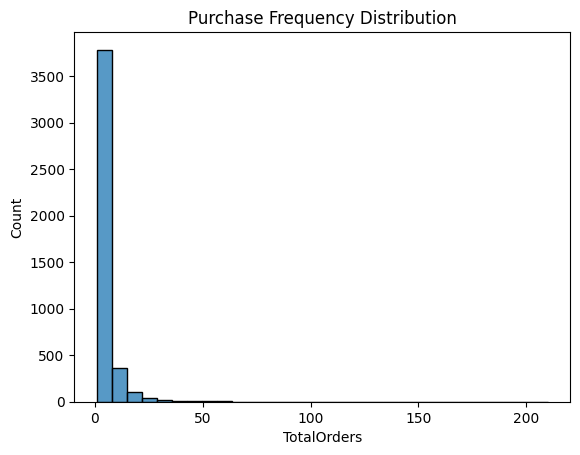

In [30]:
#4️⃣ Purchase Frequency Distribution
plt.figure()
sns.histplot(customer_data['TotalOrders'], bins=30)
plt.title("Purchase Frequency Distribution")
plt.show()

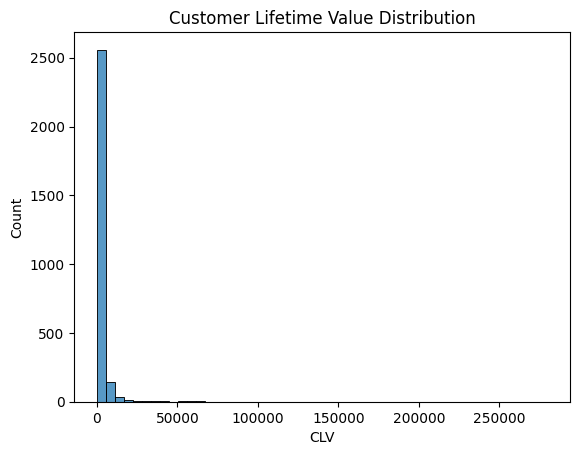

In [31]:
#5️⃣ CLV Distribution
plt.figure()
sns.histplot(customer_data['CLV'], bins=50)
plt.title("Customer Lifetime Value Distribution")
plt.show()

In [32]:
plt.savefig("../visuals/top_customers_revenue.png")

<Figure size 640x480 with 0 Axes>

In [33]:
plt.savefig("../visuals/revenue_by_country.png")

<Figure size 640x480 with 0 Axes>

In [34]:
plt.savefig("../visuals/monthly_revenue_trend.png")

<Figure size 640x480 with 0 Axes>

In [35]:
plt.savefig("../visuals/purchase_frequency_distribution.png")

<Figure size 640x480 with 0 Axes>

In [36]:
plt.savefig("../visuals/clv_distribution.png")

<Figure size 640x480 with 0 Axes>

In [1]:
import pandas as pd
import sqlite3

df = pd.read_excel("../data/raw/Online Retail.xlsx")

conn = sqlite3.connect("../data/processed/clv.db")

df.to_sql("retail", conn, if_exists="replace", index=False)

print("Database created successfully")

Database created successfully


In [2]:
import pandas as pd
import sqlite3

df = pd.read_excel("../data/raw/Online Retail.xlsx")

conn = sqlite3.connect("../data/processed/clv.db")

df.to_sql("retail", conn, if_exists="replace", index=False)

print("CLV database created successfully")

CLV database created successfully


In [3]:
import pandas as pd
import sqlite3

# Load dataset
df = pd.read_excel("../data/raw/Online Retail.xlsx")

# Connect database
conn = sqlite3.connect("../data/processed/clv.db")

# Write data into SQL table
df.to_sql("retail", conn, if_exists="replace", index=False)

print("Retail table created successfully")

Retail table created successfully
